# Global 모델링 Stage 4 — 고정 Test 최종 비교

> **경고:** 이 Notebook을 실행하면 고정 Global Test Dataset에 대한 최종 평가가 수행됩니다. Test 결과 확인 이후 Feature, Hyperparameter, Threshold를 변경하지 않습니다.

네 고정 후보(LR/XGB × 1차 42개 Feature/2차 25개 Feature)를 threshold=0.5로 평가한다. 결과를 자동 해석하거나 최종 모델을 선택하지 않는다.

In [1]:
import importlib, json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT: raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'): del sys.modules['code']
for module in ('code.model.final_evaluation', 'code.evaluation.bootstrap', 'code.evaluation.importance'):
    if module in sys.modules: importlib.reload(sys.modules[module])
from code.evaluation.bootstrap import bootstrap_confidence_intervals, paired_bootstrap_f1_difference
from code.evaluation.importance import calculate_feature_importance
from code.model.final_evaluation import (fit_final_candidates, load_final_candidates, load_stage4_cv_f1, predict_final_candidates, save_final_test_artifacts, summarize_final_predictions)
from code.pipeline.saved_results import load_saved_global_train_test
from code.preprocess.build_features import load_feature_config

RESULT_ROOT = ROOT / 'data' / 'result' / 'baseline_42features'
DATASET_PATH = RESULT_ROOT / 'datasets' / 'local_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
STAGE_1_DIR = RESULT_ROOT / 'modeling' / 'stage_1'
STAGE_3_DIR = RESULT_ROOT / 'modeling' / 'stage_3_local_group3' # 그룹명 수정
STAGE_3_5_DIR = RESULT_ROOT / 'modeling' / 'stage_3_5_local_group3' # 그룹명 수정
OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_4_local_group3' # 그룹명 수정 
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'
THRESHOLD, BOOTSTRAP_REPEATS, PERMUTATION_REPEATS = 0.5, 1000, 20
LABELS = {'lr_stage_1':'LR 튜닝 전', 'lr_stage_2':'LR 튜닝 후', 'xgb_stage_1':'XGBoost 튜닝 전', 'xgb_stage_2':'XGBoost 튜닝 후'}
COLORS = {'lr_stage_1':'#7a7a7a', 'lr_stage_2':'#0066cc', 'xgb_stage_1':'#333333', 'xgb_stage_2':'#2997ff'}
plt.rcParams.update({'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#e0e0e0','text.color':'#1d1d1f', 'font.family':'Malgun Gothic'})


In [2]:
# 이 셀부터 Test를 처음 사용한다.
from code.model.final_evaluation import FinalCandidate
from code.pipeline.run_pipeline import _subset_bundle

# 파라미터 및 피처 불러오기
with (STAGE_3_DIR / "best_params.json").open(encoding="utf-8") as file:
    stage_3_params = json.load(file)
with (STAGE_3_5_DIR / "final_refined_params.json").open(encoding="utf-8") as file:
    refined_params = json.load(file)
selected = pd.read_csv(STAGE_3_DIR / 'selected_features.csv')["feature"].tolist()

# 내부적으로는 stage_1, stage_2 키를 유지해서 뒤쪽 하드코딩된 시각화/저장 코드가 고장나지 않게 함
candidates = [
    FinalCandidate("lr_stage_1", "logistic_regression", "stage_1", tuple(selected), stage_3_params["logistic_regression"]),
    FinalCandidate("xgb_stage_1", "xgboost", "stage_1", tuple(selected), stage_3_params["xgboost"]),
    FinalCandidate("lr_stage_2", "logistic_regression", "stage_2", tuple(selected), refined_params["logistic_regression"]),
    FinalCandidate("xgb_stage_2", "xgboost", "stage_2", tuple(selected), refined_params["xgboost"]),
]

# 데이터 불러오고 로컬 직군으로 필터링
train_bundle, test_bundle = load_saved_global_train_test(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
train_bundle = _subset_bundle(train_bundle, train_bundle.metadata['job_group'] == '교육·법률·사회·공공') # 여기 바꾸기
test_bundle = _subset_bundle(test_bundle, test_bundle.metadata['job_group'] == '교육·법률·사회·공공') # 여기 바꾸기

audit = pd.DataFrame([{'train_rows':len(train_bundle.X), 'test_rows':len(test_bundle.X), 'threshold':THRESHOLD, 'bootstrap_repeats':BOOTSTRAP_REPEATS, 'permutation_repeats':PERMUTATION_REPEATS}])
display(audit)
display(pd.DataFrame([{'candidate':c.key, 'model':c.model, 'stage':c.stage, 'n_features':len(c.feature_names), 'best_params':c.params} for c in candidates]))


,train_rows,test_rows,threshold,bootstrap_repeats,permutation_repeats
0,700,202,0.5,1000,20


,candidate,model,stage,n_features,best_params
0,lr_stage_1,logistic_regression,stage_1,25,"{'C': 0.01, 'class_weight': 'balanced', 'penal..."
1,xgb_stage_1,xgboost,stage_1,25,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
2,lr_stage_2,logistic_regression,stage_2,25,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
3,xgb_stage_2,xgboost,stage_2,25,"{'subsample': 0.8, 'colsample_bytree': 0.8, 's..."


In [3]:
# Train 전체에서만 전처리 fit 및 고정 파라미터 학습.
fitted_models = fit_final_candidates(train_bundle, candidates, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG)

c:\Users\didwo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\didwo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [4]:
# 고정 Test 확률 예측과 threshold=0.5 분류.
test_predictions = predict_final_candidates(test_bundle, candidates, fitted_models, threshold=THRESHOLD)

In [ ]:
# Test metric과 CV-vs-Test 비교.
test_summary, confusion_matrices = summarize_final_predictions(test_predictions, candidates, threshold=THRESHOLD)

# stage_1은 버리고 stage_3과 stage_3_5의 CV 점수만 직접 가져오기 (내부 키인 stage_1, stage_2로 맵핑)
s3 = pd.read_csv(STAGE_3_DIR / "group3_second_stage_summary.csv") # 여기 바꾸기
s3 = s3.loc[:, ["model", "cv_f1_mean"]].assign(stage="stage_1")
s35 = pd.read_csv(STAGE_3_5_DIR / "final_tuning_summary.csv")
s35 = s35.query("stage == 'stage_3_5'").loc[:, ["model", "cv_f1_mean"]].assign(stage="stage_2")
cv_f1 = pd.concat([s3, s35], ignore_index=True)

final_comparison = test_summary.merge(cv_f1, on=['model','stage'], how='left').rename(columns={'cv_f1_mean':'cv_f1'})
final_comparison['test_f1_minus_cv_f1'] = final_comparison['test_f1'] - final_comparison['cv_f1']
display(final_comparison)


,candidate,model,stage,feature_count,test_rows,test_unique_SAMPID,positive_count,negative_count,positive_rate,predicted_positive_count,predicted_positive_rate,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,best_params,cv_f1,test_f1_minus_cv_f1
0,lr_stage_1,logistic_regression,stage_1,25,119,78,45,74,0.378151,55,0.462185,0.663866,0.545455,0.666667,0.600000,0.717868,0.555023,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.554501,0.045499
1,xgb_stage_1,xgboost,stage_1,25,119,78,45,74,0.378151,61,0.512605,0.680672,0.557377,0.755556,0.641509,0.743393,0.616476,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.584757,0.056752
2,lr_stage_2,logistic_regression,stage_2,25,119,78,45,74,0.378151,55,0.462185,0.663866,0.545455,0.666667,0.600000,0.717868,0.555023,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.554501,0.045499
3,xgb_stage_2,xgboost,stage_2,25,119,78,45,74,0.378151,67,0.563025,0.680672,0.552239,0.822222,0.660714,0.727027,0.582714,"{'subsample': 0.8, 'colsample_bytree': 0.8, 's...",0.592862,0.067853


In [41]:
# SAMPID 단위 bootstrap 1,000회. 같은 사람의 Person-Period는 함께 복원추출된다.
bootstrap_ci = pd.concat([bootstrap_confidence_intervals(frame.y_true, frame.y_proba, frame.SAMPID, threshold=THRESHOLD, n_repeats=BOOTSTRAP_REPEATS, random_state=42).query("metric == 'f1'").assign(candidate=key) for key, frame in test_predictions.items()], ignore_index=True)
pairs = [('lr_stage_2','lr_stage_1'), ('xgb_stage_2','xgb_stage_1'), ('xgb_stage_2','lr_stage_2')]
pairwise_bootstrap = pd.concat([paired_bootstrap_f1_difference(test_predictions[a].y_true, test_predictions[a].y_proba, test_predictions[b].y_proba, test_predictions[a].SAMPID, threshold=THRESHOLD, n_repeats=BOOTSTRAP_REPEATS, random_state=42, comparison=f'{a} - {b}') for a, b in pairs], ignore_index=True)
display(bootstrap_ci); display(pairwise_bootstrap)

,metric,estimate,bootstrap_mean,ci95_lower,ci95_upper,n_valid_repeats,n_repeats,bootstrap_unit,threshold,candidate
0,f1,0.600000,0.598947,0.481811,0.698113,1000,1000,SAMPID,0.5,lr_stage_1
1,f1,0.641509,0.641179,0.529400,0.737936,1000,1000,SAMPID,0.5,xgb_stage_1
2,f1,0.600000,0.598947,0.481811,0.698113,1000,1000,SAMPID,0.5,lr_stage_2
3,f1,0.660714,0.660430,0.557668,0.754394,1000,1000,SAMPID,0.5,xgb_stage_2


,comparison,point_estimate_delta_f1,bootstrap_mean_delta,ci95_lower,ci95_upper,n_repeats,bootstrap_unit,threshold
0,lr_stage_2 - lr_stage_1,0.000000,0.000000,0.000000,0.000000,1000,SAMPID,0.5
1,xgb_stage_2 - xgb_stage_1,0.019205,0.019252,-0.028891,0.073764,1000,SAMPID,0.5
2,xgb_stage_2 - lr_stage_2,0.060714,0.061483,-0.011666,0.138464,1000,SAMPID,0.5


In [42]:
# 2차 25개 Feature held-out Test PI. 재선택에 사용하지 않는 최종 진단 자료다.
candidate_by_key = {candidate.key:candidate for candidate in candidates}
permutation_importance = {}
for key in ('lr_stage_2','xgb_stage_2'):
    candidate = candidate_by_key[key]
    X_test = test_bundle.X.loc[:, list(candidate.feature_names)]
    permutation_importance[key] = calculate_feature_importance(fitted_models[key], X_test, test_bundle.y, scoring='f1', n_repeats=PERMUTATION_REPEATS, random_state=42)
display(permutation_importance['lr_stage_2']); display(permutation_importance['xgb_stage_2'])

,feature,importance_mean,importance_std,positive_repeat_count,scoring,n_repeats,rank
0,student_status,0.029635,0.019459,18,f1,20,1
1,education_level,0.028736,0.021357,19,f1,20,2
2,has_employment_certificate,0.025653,0.011133,19,f1,20,3
3,major_group,0.021697,0.017466,18,f1,20,4
4,recent_job_search,0.021114,0.016681,16,f1,20,5
5,currently_preparing_exam,0.019206,0.013059,16,f1,20,6
6,prep_effort_08,0.014956,0.022048,16,f1,20,7
7,has_certificate,0.011241,0.014013,15,f1,20,8
8,recent_employment_prep,0.010976,0.008026,17,f1,20,9
9,student_type,0.010337,0.013551,16,f1,20,10


,feature,importance_mean,importance_std,positive_repeat_count,scoring,n_repeats,rank
0,major_group,0.061025,0.018881,20,f1,20,1
1,months_since_graduation,0.035142,0.019183,19,f1,20,2
2,gender,0.031722,0.016679,19,f1,20,3
3,education_level,0.023087,0.009991,19,f1,20,4
4,student_status,0.019701,0.012383,19,f1,20,5
5,exam_prep_experience,0.019097,0.007998,20,f1,20,6
6,age,0.018456,0.027569,15,f1,20,7
7,currently_preparing_exam,0.018314,0.006338,20,f1,20,8
8,has_certificate,0.013554,0.009090,17,f1,20,9
9,has_employment_certificate,0.011419,0.009354,16,f1,20,10


In [43]:
# 사람이 실행했을 때만 Test 결과 artifact를 저장한다.
artifact_paths = save_final_test_artifacts(output_dir=OUTPUT_DIR, summary=final_comparison, bootstrap_ci=bootstrap_ci, pairwise_bootstrap=pairwise_bootstrap, predictions=test_predictions, permutation_importance=permutation_importance, confusion_matrices=confusion_matrices)
display(pd.DataFrame({'artifact':list(artifact_paths), 'path':[str(path) for path in artifact_paths.values()]}))

,artifact,path
0,final_test_summary,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
1,final_test_bootstrap_ci,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
2,final_test_pairwise_bootstrap,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
3,final_test_predictions,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
4,final_model_comparison,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
5,confusion_matrices,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
6,lr_stage_2_permutation_importance,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
7,xgb_stage_2_permutation_importance,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...


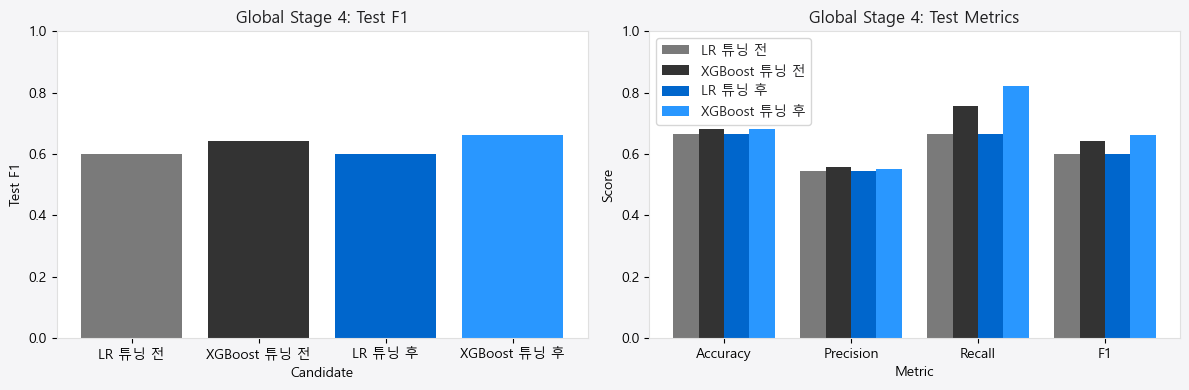

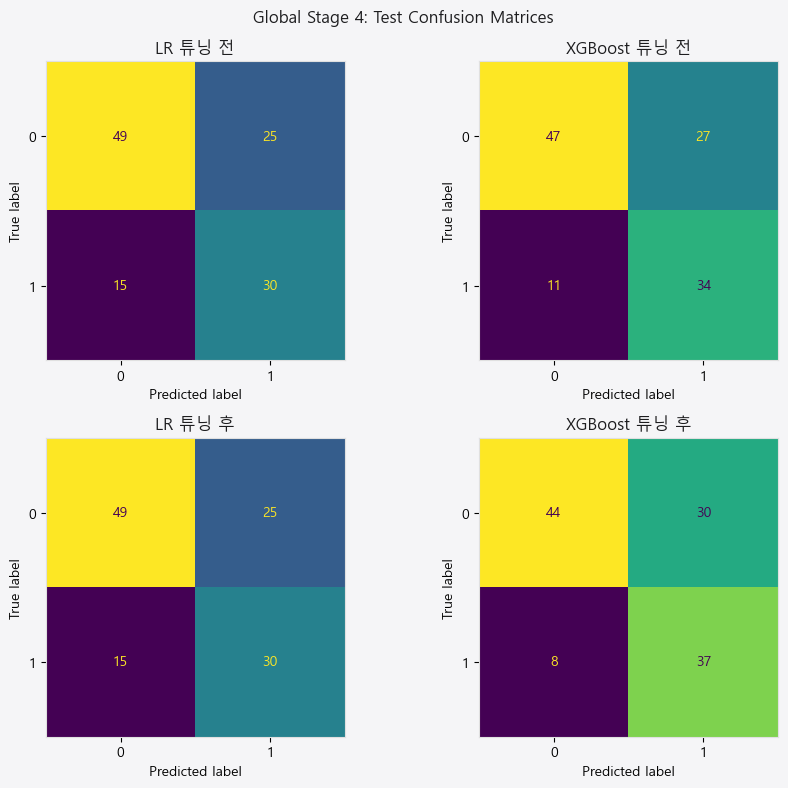

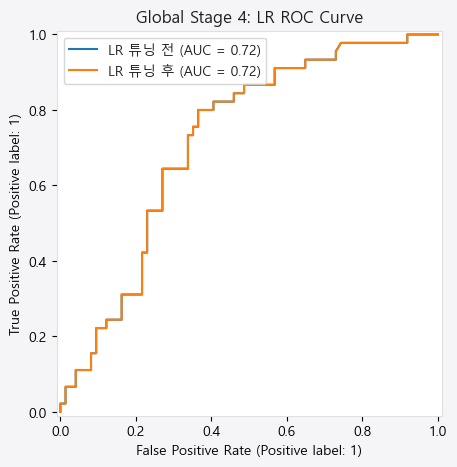

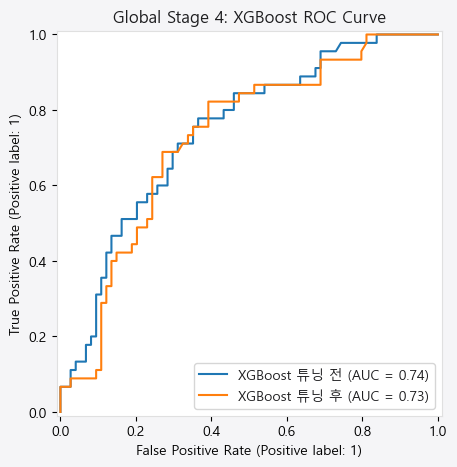

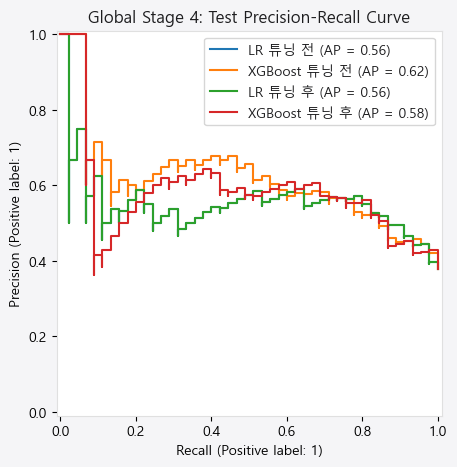

In [44]:
# Test F1 및 Accuracy/Precision/Recall/F1.
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar([LABELS[k] for k in final_comparison.candidate], final_comparison.test_f1, color=[COLORS[k] for k in final_comparison.candidate]); axes[0].set(title='Global Stage 4: Test F1', xlabel='Candidate', ylabel='Test F1', ylim=(0,1))
metrics = ['test_accuracy','test_precision','test_recall','test_f1']; x=np.arange(4); width=.2
for i,row in enumerate(final_comparison.itertuples()): axes[1].bar(x+(i-1.5)*width,[getattr(row,m) for m in metrics],width,label=LABELS[row.candidate],color=COLORS[row.candidate])
axes[1].set(title='Global Stage 4: Test Metrics', xlabel='Metric', ylabel='Score', ylim=(0,1)); axes[1].set_xticks(x,['Accuracy','Precision','Recall','F1']); axes[1].legend(); plt.tight_layout(); plt.show()

# 네 confusion matrix, 두 모델군별 ROC, 네 모델 PR curve.
fig, axes = plt.subplots(2,2,figsize=(9,8))
for ax,(key,frame) in zip(axes.ravel(),test_predictions.items()): ConfusionMatrixDisplay.from_predictions(frame.y_true,frame.y_pred,ax=ax,colorbar=False); ax.set_title(LABELS[key])
fig.suptitle('Global Stage 4: Test Confusion Matrices'); plt.tight_layout(); plt.show()
for family,keys in [('LR',('lr_stage_1','lr_stage_2')),('XGBoost',('xgb_stage_1','xgb_stage_2'))]:
    fig,ax=plt.subplots(figsize=(6,5))
    for key in keys: RocCurveDisplay.from_predictions(test_predictions[key].y_true,test_predictions[key].y_proba,name=LABELS[key],ax=ax)
    ax.set_title(f'Global Stage 4: {family} ROC Curve'); ax.legend(); plt.show()
fig,ax=plt.subplots(figsize=(6,5))
for key,frame in test_predictions.items(): PrecisionRecallDisplay.from_predictions(frame.y_true,frame.y_proba,name=LABELS[key],ax=ax)
ax.set_title('Global Stage 4: Test Precision-Recall Curve'); ax.legend(); plt.show()

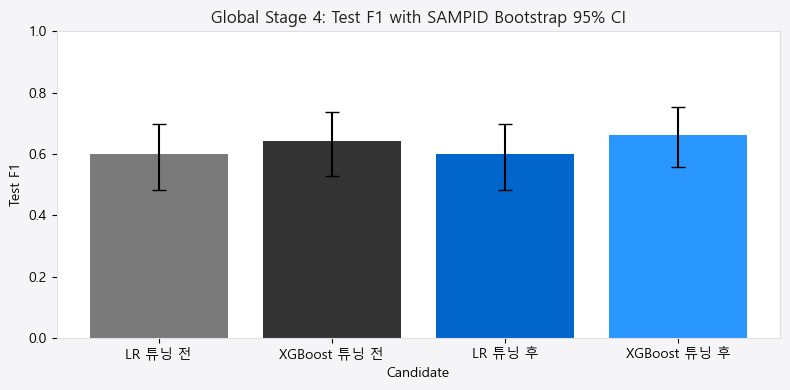

,comparison,point_estimate_delta_f1,bootstrap_mean_delta,ci95_lower,ci95_upper,n_repeats,bootstrap_unit,threshold
0,lr_stage_2 - lr_stage_1,0.000000,0.000000,0.000000,0.000000,1000,SAMPID,0.5
1,xgb_stage_2 - xgb_stage_1,0.019205,0.019252,-0.028891,0.073764,1000,SAMPID,0.5


C:\Users\didwo\AppData\Local\Temp\ipykernel_29336\2700246737.py:6: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  frame=permutation_importance[key].sort_values('importance_mean'); fig,ax=plt.subplots(figsize=(7,7)); ax.barh(frame.feature,frame.importance_mean,xerr=frame.importance_std,color=COLORS[key]); ax.set(title=f'{LABELS[key]}: Held-out Test Permutation Importance',xlabel='F1 importance',ylabel='Original feature'); plt.tight_layout(); plt.show()
C:\Users\didwo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


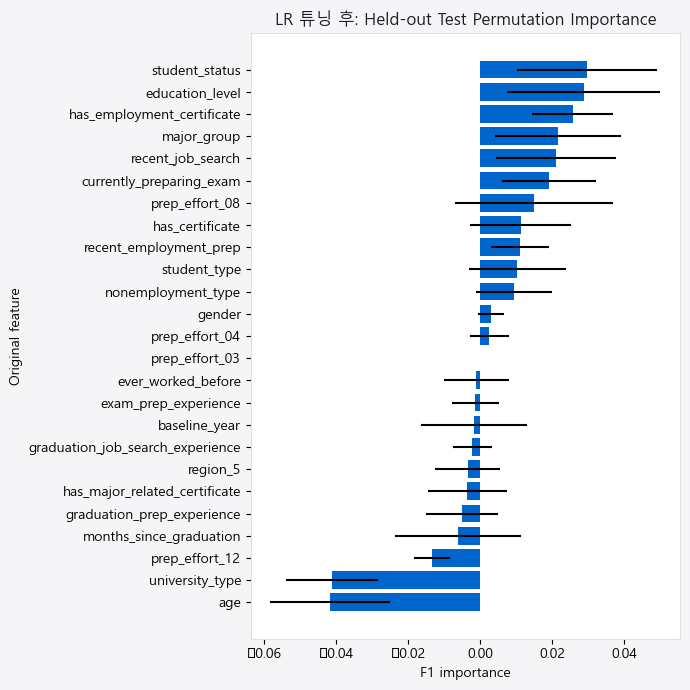

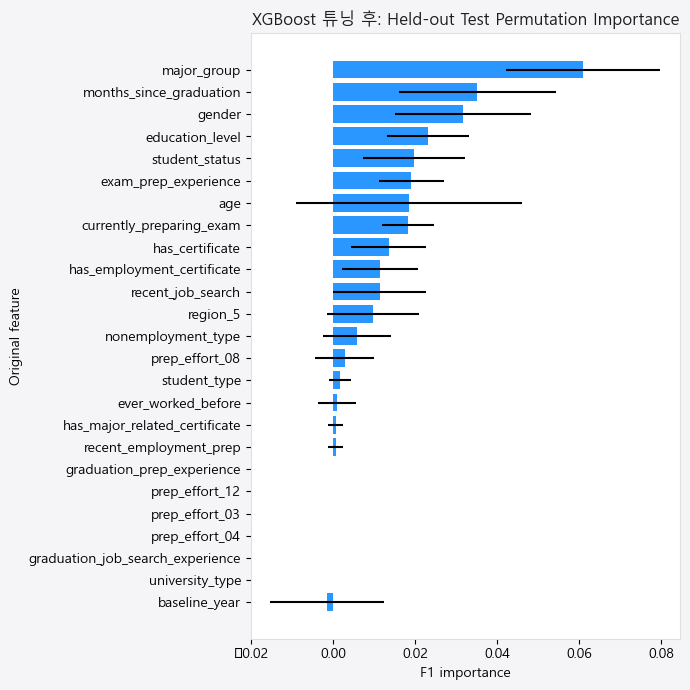

,model,stage,feature_count,cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,ci95_lower,ci95_upper
0,logistic_regression,stage_1,25,0.554501,0.663866,0.545455,0.666667,0.600000,0.717868,0.555023,0.481811,0.698113
1,xgboost,stage_1,25,0.584757,0.680672,0.557377,0.755556,0.641509,0.743393,0.616476,0.529400,0.737936
2,logistic_regression,stage_2,25,0.554501,0.663866,0.545455,0.666667,0.600000,0.717868,0.555023,0.481811,0.698113
3,xgboost,stage_2,25,0.592862,0.680672,0.552239,0.822222,0.660714,0.727027,0.582714,0.557668,0.754394


In [45]:
# Bootstrap CI, Feature selection 전후 ΔF1, 2차 PI.
ci = bootstrap_ci.set_index('candidate').loc[final_comparison.candidate]
fig,ax=plt.subplots(figsize=(8,4)); values=final_comparison.test_f1.to_numpy(); errors=np.vstack([values-ci.ci95_lower.to_numpy(),ci.ci95_upper.to_numpy()-values]); ax.bar([LABELS[k] for k in final_comparison.candidate],values,yerr=errors,capsize=5,color=[COLORS[k] for k in final_comparison.candidate]); ax.set(title='Global Stage 4: Test F1 with SAMPID Bootstrap 95% CI',xlabel='Candidate',ylabel='Test F1',ylim=(0,1)); plt.tight_layout(); plt.show()
delta = pairwise_bootstrap[pairwise_bootstrap.comparison.isin(['lr_stage_2 - lr_stage_1','xgb_stage_2 - xgb_stage_1'])]; display(delta)
for key in ('lr_stage_2','xgb_stage_2'):
    frame=permutation_importance[key].sort_values('importance_mean'); fig,ax=plt.subplots(figsize=(7,7)); ax.barh(frame.feature,frame.importance_mean,xerr=frame.importance_std,color=COLORS[key]); ax.set(title=f'{LABELS[key]}: Held-out Test Permutation Importance',xlabel='F1 importance',ylabel='Original feature'); plt.tight_layout(); plt.show()

# 발표용 최종 표: 수치만 표시하며 자동 선택·해석을 하지 않는다.
presentation_columns=['model','stage','feature_count','cv_f1','test_accuracy','test_precision','test_recall','test_f1','test_roc_auc','test_average_precision']
presentation = final_comparison.merge(ci[['ci95_lower','ci95_upper']],left_on='candidate',right_index=True,how='left').loc[:,presentation_columns+['ci95_lower','ci95_upper']]
display(presentation)